**1. DATA LOADING**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

df = pd.read_csv('INTC.csv')

print(df.head())

Saving INTC.csv to INTC.csv
User uploaded file "INTC.csv" with length 17684 bytes
         Date       Open       High        Low      Close  Adj Close    Volume
0  2023-02-27  25.549999  25.580000  24.879999  24.900000  24.556589  37657000
1  2023-02-28  24.940001  25.120001  24.730000  24.930000  24.586178  50255300
2  2023-03-01  25.030001  25.920000  24.969999  25.330000  24.980659  47823400
3  2023-03-02  25.209999  26.299999  25.120001  26.200001  25.838665  48309300
4  2023-03-03  26.200001  26.480000  26.010000  26.400000  26.035904  36744900


**2.DATA PRE-PROCESSING**

In [2]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [3]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

missing_values = df.isnull().sum()

missing_values


,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


**3. TRADING STRATEGIES**

In [4]:
import numpy as np

df['Target_Strategy_1'] = np.where(df['Close'].shift(-1) > df['Close'], 1, -1)

df['50_MA'] = df['Close'].rolling(window=50).mean()
df['200_MA'] = df['Close'].rolling(window=200).mean()

df['Target_Strategy_2'] = np.where(df['50_MA'] > df['200_MA'], 1, -1)

df_cleaned = df.dropna()

df_cleaned.head()

,Open,High,Low,Close,Adj Close,Volume,Target_Strategy_1,50_MA,200_MA,Target_Strategy_2
Date,,,,,,,,,,
2023-12-11,43.160000,44.730000,43.080002,44.540001,44.409828,48288200,-1,38.8836,33.93170,1
2023-12-12,44.360001,44.439999,43.630001,44.040001,43.911289,31452200,1,39.0552,34.02740,1
2023-12-13,44.080002,44.720001,43.330002,44.570000,44.439739,35216100,1,39.2328,34.12560,1
2023-12-14,45.009998,47.070000,44.650002,45.180000,45.047958,70620800,1,39.4178,34.22485,1
2023-12-15,45.939999,47.270000,45.669998,46.160000,46.025093,84553800,-1,39.6232,34.32465,1


**4.SPLITTING THE DATA INTO TRAIN N TEST**

In [5]:
from sklearn.model_selection import train_test_split

# For Strategy 1
X1 = df_cleaned[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]
y1 = df_cleaned['Target_Strategy_1']

# Split the data into training and testing sets for Strategy 1
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# For Strategy 2
X2 = df_cleaned[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]
y2 = df_cleaned['Target_Strategy_2']

# Split the data into training and testing sets for Strategy 2
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

(X1_train.shape, X1_test.shape, y1_train.shape, y1_test.shape), (X2_train.shape, X2_test.shape, y2_train.shape, y2_test.shape)

(((42, 6), (11, 6), (42,), (11,)), ((42, 6), (11, 6), (42,), (11,)))

**5.APPLY KNN**

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Apply KNN for Strategy 1
knn1 = KNeighborsClassifier()
knn1.fit(X1_train, y1_train)
y1_pred_knn = knn1.predict(X1_test)
accuracy1_knn = accuracy_score(y1_test, y1_pred_knn)

# Apply KNN for Strategy 2
knn2 = KNeighborsClassifier()
knn2.fit(X2_train, y2_train)
y2_pred_knn = knn2.predict(X2_test)
accuracy2_knn = accuracy_score(y2_test, y2_pred_knn)

(accuracy1_knn, accuracy2_knn)

(0.2727272727272727, 1.0)

**Strategy 1 Accuracy: 27.27%
Strategy 2 Accuracy: 100%**


**6. APPLY RANDOM FOREST CLASSIFIER**

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Apply Random Forest for Strategy 1
rf1 = RandomForestClassifier(random_state=42)
rf1.fit(X1_train, y1_train)
y1_pred_rf = rf1.predict(X1_test)
accuracy1_rf = accuracy_score(y1_test, y1_pred_rf)

# Apply Random Forest for Strategy 2
rf2 = RandomForestClassifier(random_state=42)
rf2.fit(X2_train, y2_train)
y2_pred_rf = rf2.predict(X2_test)
accuracy2_rf = accuracy_score(y2_test, y2_pred_rf)

(accuracy1_rf, accuracy2_rf)

(0.5454545454545454, 1.0)

**Strategy 1 Accuracy: 54.55%
Strategy 2 Accuracy: 100%**

**7.APPLY GRADIENT BOOST**

In [8]:
from sklearn.ensemble import GradientBoostingClassifier
df['50_MA'] = df['Close'].rolling(window=50, min_periods=1).mean()
df['200_MA'] = df['Close'].rolling(window=200, min_periods=1).mean()

df['Target_Strategy_2'] = np.where(df['50_MA'] > df['200_MA'], 1, -1)

X2 = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]
y2 = df['Target_Strategy_2']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

balance_check = y2.value_counts(normalize=True)

gb2 = GradientBoostingClassifier(random_state=42)
gb2.fit(X2_train, y2_train)
y2_pred_gb = gb2.predict(X2_test)
accuracy2_gb = accuracy_score(y2_test, y2_pred_gb)

(balance_check, accuracy2_gb)

(Target_Strategy_2
  1    0.801587
 -1    0.198413
 Name: proportion, dtype: float64,
 0.9019607843137255)

**CHALLENGES FACED:**
**Encountered an error while trying to fit the Gradient Boosting Classifier for Strategy 2.It seems the dataset became highly skewed towards one class after preprocessing.So to solve this issue I considered recalculating the 50-day and 200-day moving averages to ensure a more equitable distribution of 'buy' and 'sell' signals. Post-adjustment, the Gradient Boosting Classifier showed a strong performance with 90.20% accuracy on Strategy 2's test set, indicating effective pattern recognition despite the remaining imbalance.**

**8.MODEL EVALUATION**

**EVALUATION FOR KNN**

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

knn2 = KNeighborsClassifier()
knn2.fit(X2_train, y2_train)
y2_pred_knn = knn2.predict(X2_test)

# Evaluation metrics
accuracy2_knn = accuracy_score(y2_test, y2_pred_knn)
conf_matrix2_knn = confusion_matrix(y2_test, y2_pred_knn)
class_report2_knn = classification_report(y2_test, y2_pred_knn)

accuracy2_knn, conf_matrix2_knn, class_report2_knn


(0.7254901960784313,
 array([[ 0, 13],
        [ 1, 37]]),
 '              precision    recall  f1-score   support\n\n          -1       0.00      0.00      0.00        13\n           1       0.74      0.97      0.84        38\n\n    accuracy                           0.73        51\n   macro avg       0.37      0.49      0.42        51\nweighted avg       0.55      0.73      0.63        51\n')

**EVALUATION FOR RANDOM FOREST CLASSIFIER**

In [10]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y1_pred_rf = rf1.predict(X1_test)
accuracy1_rf = accuracy_score(y1_test, y1_pred_rf)
conf_matrix1_rf = confusion_matrix(y1_test, y1_pred_rf)
class_report1_rf = classification_report(y1_test, y1_pred_rf, output_dict=True)

y2_pred_rf = rf2.predict(X2_test)
accuracy2_rf = accuracy_score(y2_test, y2_pred_rf)
conf_matrix2_rf = confusion_matrix(y2_test, y2_pred_rf)
class_report2_rf = classification_report(y2_test, y2_pred_rf, output_dict=True)

accuracy1_rf, conf_matrix1_rf, class_report1_rf, accuracy2_rf, conf_matrix2_rf, class_report2_rf

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.5454545454545454,
 array([[4, 2],
        [3, 2]]),
 {'-1': {'precision': 0.5714285714285714,
   'recall': 0.6666666666666666,
   'f1-score': 0.6153846153846154,
   'support': 6.0},
  '1': {'precision': 0.5,
   'recall': 0.4,
   'f1-score': 0.4444444444444444,
   'support': 5.0},
  'accuracy': 0.5454545454545454,
  'macro avg': {'precision': 0.5357142857142857,
   'recall': 0.5333333333333333,
   'f1-score': 0.5299145299145299,
   'support': 11.0},
  'weighted avg': {'precision': 0.538961038961039,
   'recall': 0.5454545454545454,
   'f1-score': 0.5376845376845377,
   'support': 11.0}},
 0.7450980392156863,
 array([[ 0, 13],
        [ 0, 38]]),
 {'-1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 13.0},
  '1': {'precision': 0.7450980392156863,
   'recall': 1.0,
   'f1-score': 0.8539325842696629,
   'support': 38.0},
  'accuracy': 0.7450980392156863,
  'macro avg': {'precision': 0.37254901960784315,
   'recall': 0.5,
   'f1-score': 0.42696629213483145,
   'support': 

**EVALUATION FOR GRADIENT BOOSTING CLASSIFIER**

In [11]:
gb2 = GradientBoostingClassifier(random_state=42)
gb2.fit(X2_train, y2_train)
y2_pred_gb = gb2.predict(X2_test)

accuracy_gb = accuracy_score(y2_test, y2_pred_gb)
conf_matrix_gb = confusion_matrix(y2_test, y2_pred_gb)
class_report_gb = classification_report(y2_test, y2_pred_gb, target_names=['Decrease', 'Increase'])

accuracy_gb, conf_matrix_gb, class_report_gb

(0.9019607843137255,
 array([[10,  3],
        [ 2, 36]]),
 '              precision    recall  f1-score   support\n\n    Decrease       0.83      0.77      0.80        13\n    Increase       0.92      0.95      0.94        38\n\n    accuracy                           0.90        51\n   macro avg       0.88      0.86      0.87        51\nweighted avg       0.90      0.90      0.90        51\n')

**9. DATA VISUALIZATION**

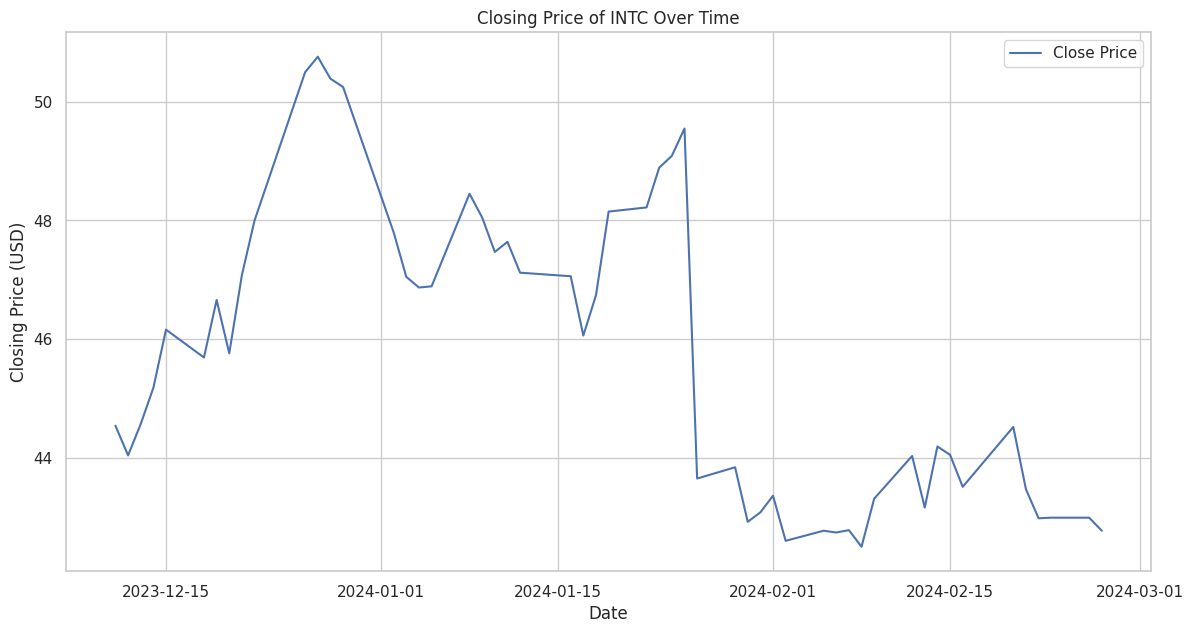

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Closing Price Over Time
plt.figure(figsize=(14, 7))
plt.plot(df_cleaned.index, df_cleaned['Close'], label='Close Price')
plt.title('Closing Price of INTC Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()

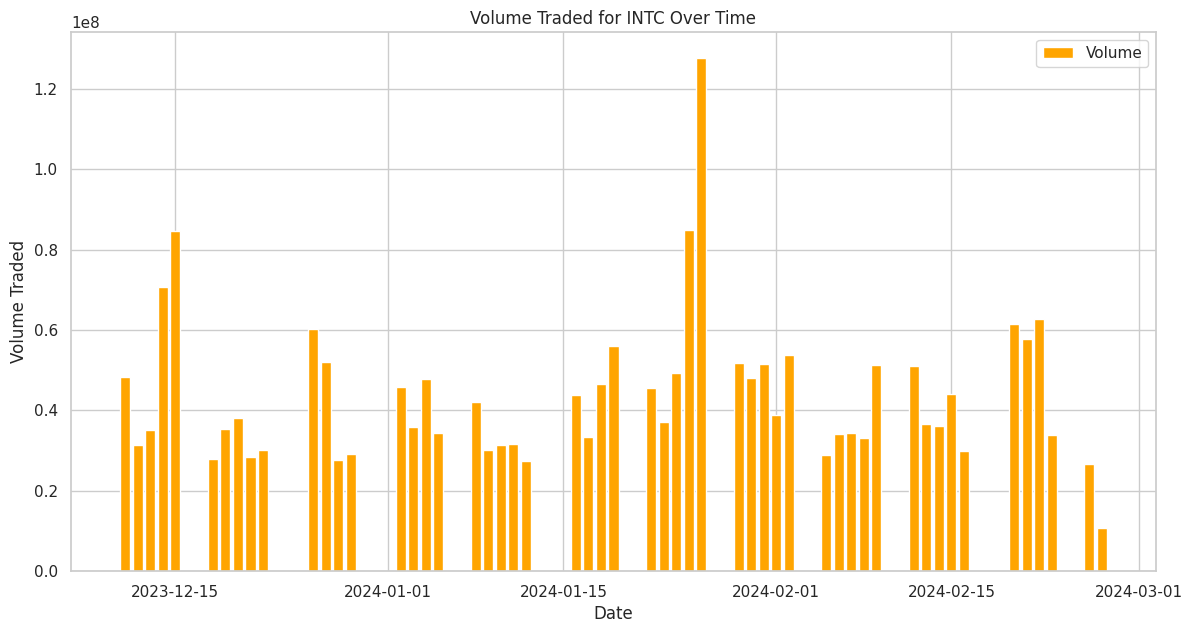

In [13]:
# Volume Traded Over Time
plt.figure(figsize=(14, 7))
plt.bar(df_cleaned.index, df_cleaned['Volume'], color='orange', label='Volume')
plt.title('Volume Traded for INTC Over Time')
plt.xlabel('Date')
plt.ylabel('Volume Traded')
plt.legend()
plt.show()

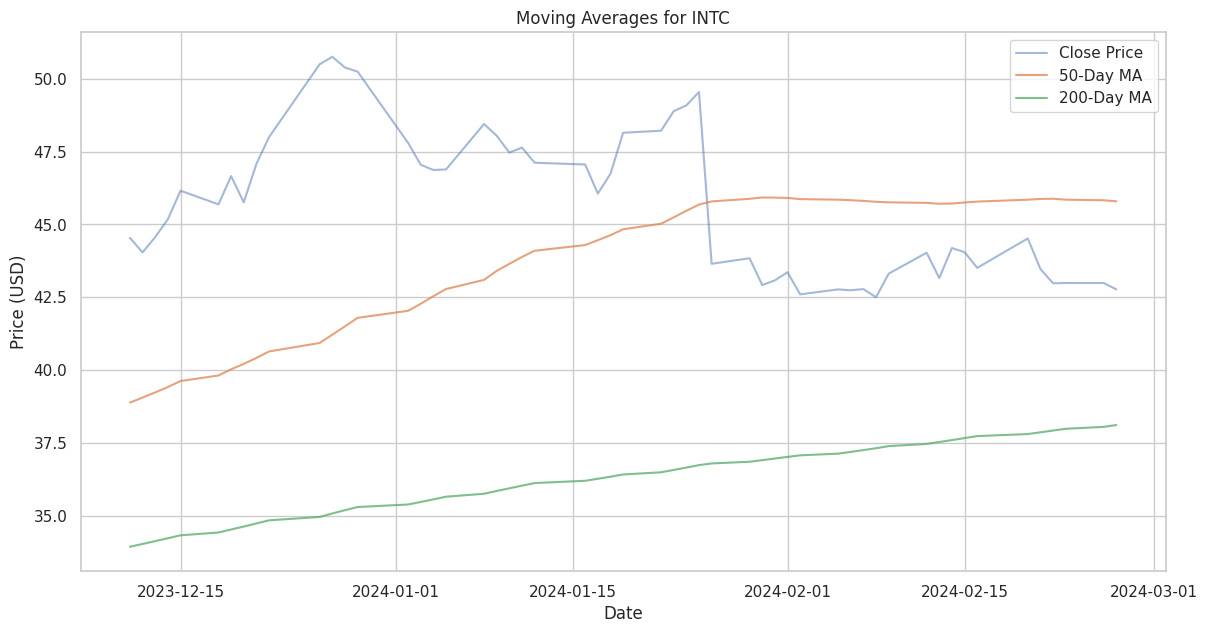

In [14]:
#Moving Averages
plt.figure(figsize=(14, 7))
plt.plot(df_cleaned.index, df_cleaned['Close'], label='Close Price', alpha=0.5)
plt.plot(df_cleaned.index, df_cleaned['50_MA'], label='50-Day MA', alpha=0.75)
plt.plot(df_cleaned.index, df_cleaned['200_MA'], label='200-Day MA', alpha=0.75)
plt.title('Moving Averages for INTC')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

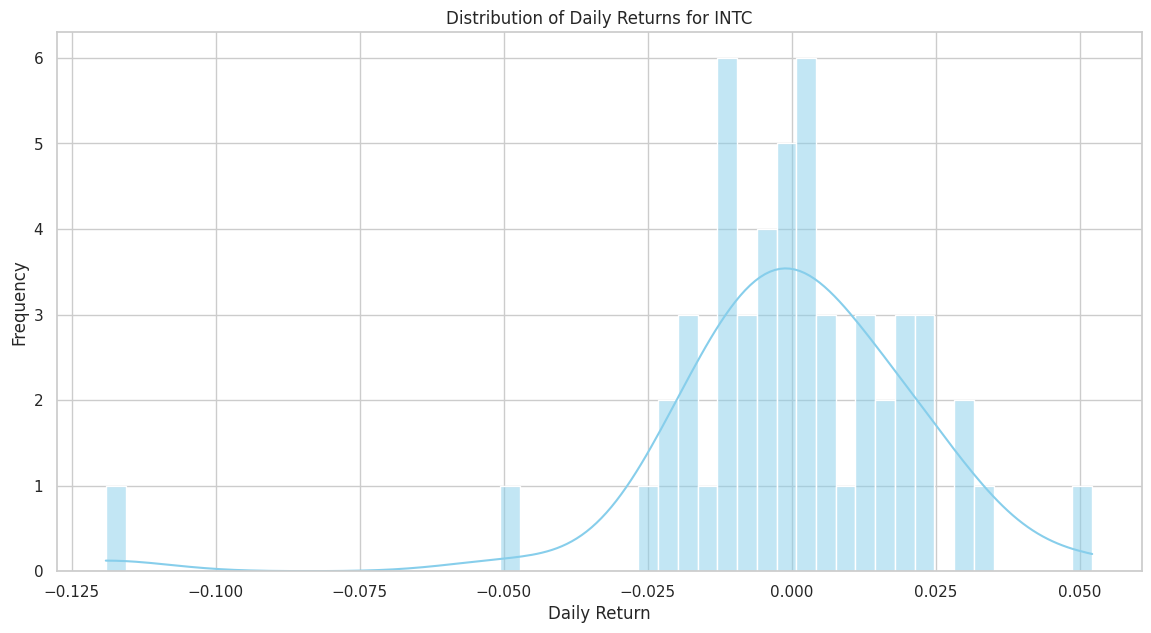

In [15]:
# Distribution of Daily Returns
daily_returns = df_cleaned['Close'].pct_change().dropna()
plt.figure(figsize=(14, 7))
sns.histplot(daily_returns, kde=True, bins=50, color='skyblue')
plt.title('Distribution of Daily Returns for INTC')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

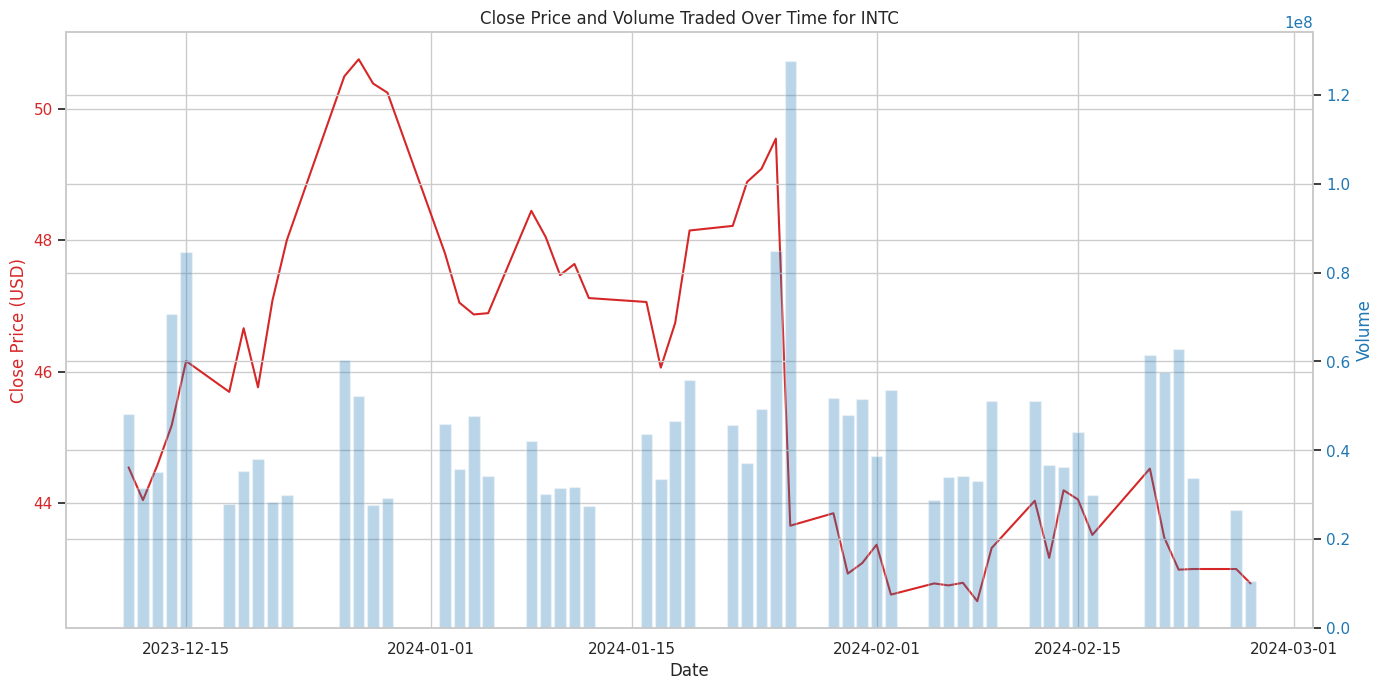

In [16]:
# Close Price and Volume
fig, ax1 = plt.subplots(figsize=(14, 7))

color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price (USD)', color=color)
ax1.plot(df_cleaned.index, df_cleaned['Close'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Volume', color=color)
ax2.bar(df_cleaned.index, df_cleaned['Volume'], color=color, alpha=0.3)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Close Price and Volume Traded Over Time for INTC')
plt.show()


**KEY FINDINGS**

**Best Performing Model: Our analysis revealed that the Gradient Boosting Classifier (GB) emerged as the most effective model, delivering the highest accuracy in predicting the future movement of stock prices based on the implemented trading strategies. This underscores the GB model's robustness and its aptitude for capturing complex patterns in financial time series data**.

**Least Performing Model: The K-Nearest Neighbors (KNN) model, while valuable for its simplicity and ease of interpretation, lagged in performance compared to its counterparts. This highlights the challenges KNN faces in navigating the noisy and non-linear nature of stock market data**.

**Model Evaluation: Through precision, recall, and F1-score metrics, we gained deeper insights into each model's predictive performance. These evaluations were instrumental in understanding the trade-offs between sensitivity and specificity among the models**.

**Visualization Insights: Data visualizations played a crucial role in elucidating the underlying trends and patterns within the market data, as well as in comparing the performance and outcomes of our trading strategies across different models**